In [1]:
import pandas as pd

In [2]:
import numpy as np

In [3]:
import matplotlib.pyplot as plt
import seaborn as sns

In [4]:
sns.set_theme(style="whitegrid")
print("Libraries imported successfully!")

Libraries imported successfully!


In [5]:
df_train = pd.read_csv('../data/train.csv')
df_train.head()

,Id,MSSubClass,MSZoning,LotFrontage,LotArea,Street,Alley,LotShape,LandContour,Utilities,...,PoolArea,PoolQC,Fence,MiscFeature,MiscVal,MoSold,YrSold,SaleType,SaleCondition,SalePrice
0,1,60,RL,65.0,8450,Pave,NaN,Reg,Lvl,AllPub,...,0,NaN,NaN,NaN,0,2,2008,WD,Normal,208500
1,2,20,RL,80.0,9600,Pave,NaN,Reg,Lvl,AllPub,...,0,NaN,NaN,NaN,0,5,2007,WD,Normal,181500
2,3,60,RL,68.0,11250,Pave,NaN,IR1,Lvl,AllPub,...,0,NaN,NaN,NaN,0,9,2008,WD,Normal,223500
3,4,70,RL,60.0,9550,Pave,NaN,IR1,Lvl,AllPub,...,0,NaN,NaN,NaN,0,2,2006,WD,Abnorml,140000
4,5,60,RL,84.0,14260,Pave,NaN,IR1,Lvl,AllPub,...,0,NaN,NaN,NaN,0,12,2008,WD,Normal,250000


In [6]:
print(f"Dataset Shape: {df_train.shape[0]} row and {df_train.shape[1]} columns.\n")
df_train.info()

Dataset Shape: 1460 row and 81 columns.

<class 'pandas.DataFrame'>
RangeIndex: 1460 entries, 0 to 1459
Data columns (total 81 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   Id             1460 non-null   int64  
 1   MSSubClass     1460 non-null   int64  
 2   MSZoning       1460 non-null   str    
 3   LotFrontage    1201 non-null   float64
 4   LotArea        1460 non-null   int64  
 5   Street         1460 non-null   str    
 6   Alley          91 non-null     str    
 7   LotShape       1460 non-null   str    
 8   LandContour    1460 non-null   str    
 9   Utilities      1460 non-null   str    
 10  LotConfig      1460 non-null   str    
 11  LandSlope      1460 non-null   str    
 12  Neighborhood   1460 non-null   str    
 13  Condition1     1460 non-null   str    
 14  Condition2     1460 non-null   str    
 15  BldgType       1460 non-null   str    
 16  HouseStyle     1460 non-null   str    
 17  OverallQual    1460 no

In [7]:
plt.figure(figsize=(10, 6))

<Figure size 1000x600 with 0 Axes>

<Figure size 1000x600 with 0 Axes>

<Axes: xlabel='SalePrice', ylabel='Count'>

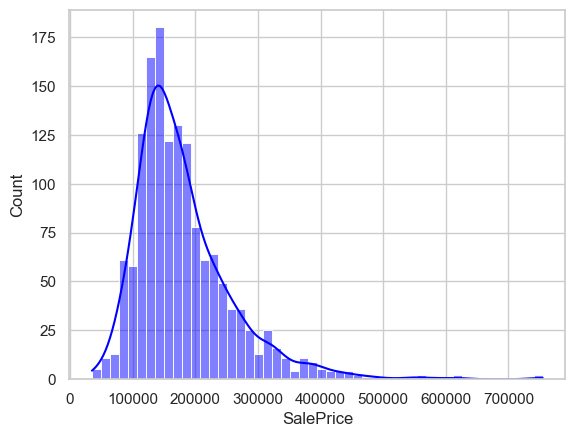

In [8]:
sns.histplot(df_train['SalePrice'], kde=True, color='blue', bins=50)

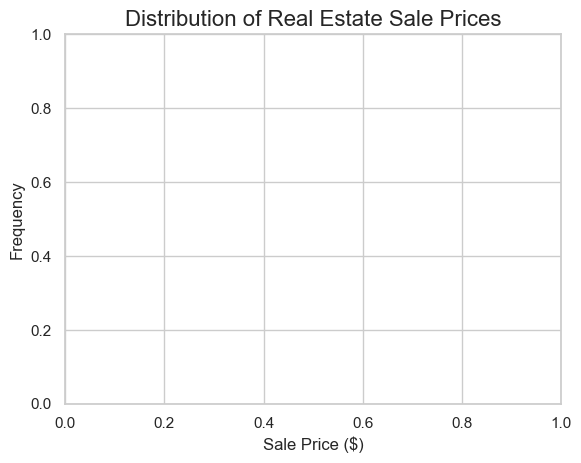

In [9]:
plt.title('Distribution of Real Estate Sale Prices', fontsize=16)
plt.xlabel('Sale Price ($)', fontsize=12)
plt.ylabel('Frequency', fontsize=12)
plt.show()

In [10]:
numeric_cols = df_train.select_dtypes(include=[np.number])
correlations = numeric_cols.corr()['SalePrice'].sort_values(ascending=False)
print("Top 10 Features that drive House Prices up:\n")
print(correlations.head(11))

Top 10 Features that drive House Prices up:

SalePrice       1.000000
OverallQual     0.790982
GrLivArea       0.708624
GarageCars      0.640409
GarageArea      0.623431
TotalBsmtSF     0.613581
1stFlrSF        0.605852
FullBath        0.560664
TotRmsAbvGrd    0.533723
YearBuilt       0.522897
YearRemodAdd    0.507101
Name: SalePrice, dtype: float64


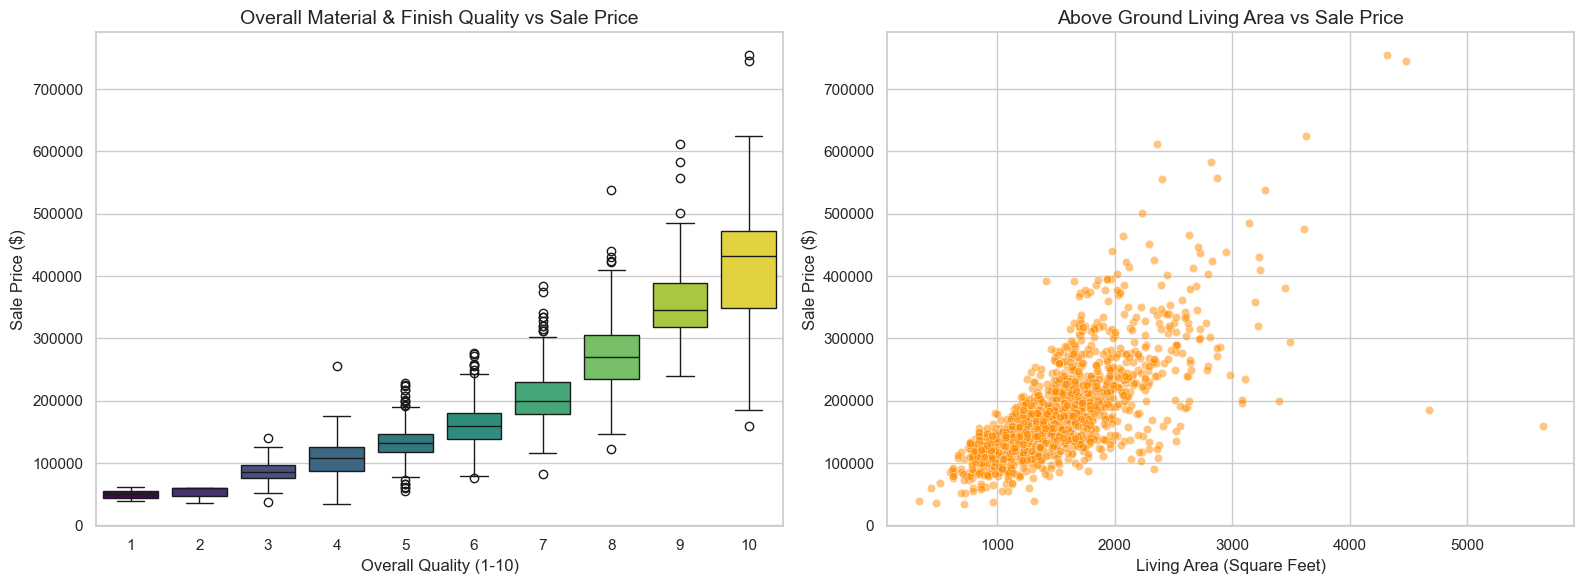

In [11]:
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

sns.boxplot(x='OverallQual', y='SalePrice', data=df_train, ax=axes[0], hue='OverallQual', palette='viridis', legend=False)
axes[0].set_title('Overall Material & Finish Quality vs Sale Price', fontsize=14)
axes[0].set_xlabel('Overall Quality (1-10)')
axes[0].set_ylabel('Sale Price ($)')

sns.scatterplot(x='GrLivArea', y='SalePrice', data=df_train, ax=axes[1], alpha=0.5, color='darkorange')
axes[1].set_title('Above Ground Living Area vs Sale Price', fontsize=14)
axes[1].set_xlabel('Living Area (Square Feet)')
axes[1].set_ylabel('Sale Price ($)')

plt.tight_layout()
plt.show()

In [12]:
missing_data = df_train.isnull().sum()
missing_percent = (missing_data / len(df_train)) * 100

missing_df = pd.DataFrame({'Missing Count': missing_data, 'Percentage (%)': missing_percent})

missing_df = missing_df[missing_df['Missing Count'] > 0].sort_values(by='Percentage (%)', ascending=False)

print("The Missing Data Audit:\n")
print(missing_df.head(10))

The Missing Data Audit:

              Missing Count  Percentage (%)
PoolQC                 1453       99.520548
MiscFeature            1406       96.301370
Alley                  1369       93.767123
Fence                  1179       80.753425
MasVnrType              872       59.726027
FireplaceQu             690       47.260274
LotFrontage             259       17.739726
GarageType               81        5.547945
GarageYrBlt              81        5.547945
GarageFinish             81        5.547945


In [13]:
cols_to_drop = ['PoolQC', 'MiscFeature', 'Alley', 'Fence']
df_train_cleaned = df_train.drop(columns=cols_to_drop)

numeric_cols = df_train_cleaned.select_dtypes(include=[np.number]).columns
df_train_cleaned[numeric_cols] = df_train_cleaned[numeric_cols].fillna(df_train_cleaned[numeric_cols].median())

categorical_cols = df_train_cleaned.select_dtypes(exclude=[np.number]).columns
df_train_cleaned[categorical_cols] = df_train_cleaned[categorical_cols].fillna("None")

print("Missing Data Audit after cleaning:")
print(df_train_cleaned.isnull().sum().max())

Missing Data Audit after cleaning:
0


In [14]:
df_train_cleaned['TotalSF'] = df_train_cleaned['TotalBsmtSF'] + df_train_cleaned['1stFlrSF'] + df_train_cleaned['2ndFlrSF']
new_correlation = df_train_cleaned['TotalSF'].corr(df_train_cleaned['SalePrice'])
print(f"Correlation of our new TotalSF feature with SalePrice: {new_correlation:.4f}")

Correlation of our new TotalSF feature with SalePrice: 0.7823


In [15]:
target = df_train_cleaned['SalePrice']
features = df_train_cleaned.drop(columns=['SalePrice', 'Id'])
features_encoded = pd.get_dummies(features)

print(f"Original feature count: {features.shape[1]}")
print(f"Encoded feature count: {features_encoded.shape[1]}")

Original feature count: 76
Encoded feature count: 287


In [16]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(features_encoded, target, test_size=0.2, random_state=42)

print(f"Training data (what the model learns from): {X_train.shape[0]} houses")
print(f"Testing data (what we test it on): {X_test.shape[0]} houses")

Training data (what the model learns from): 1168 houses
Testing data (what we test it on): 292 houses


In [17]:
from sklearn.ensemble import RandomForestRegressor

rf_model = RandomForestRegressor(n_estimators=100, random_state=42)

print("Training the Random Forest model... (This might take a few seconds)")

rf_model.fit(X_train, y_train)

print("Model training complete!")

Training the Random Forest model... (This might take a few seconds)
Model training complete!


In [18]:
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

predictions = rf_model.predict(X_test)

mae = mean_absolute_error(y_test, predictions)
rmse = np.sqrt(mean_squared_error(y_test, predictions))
r2 = r2_score(y_test, predictions)

print("Model Performance Metrics:\n")
print(f"Mean Absolute Error (MAE): ${mae:,.2f}")
print(f"Root Mean Squared Error (RMSE): ${rmse:,.2f}")
print(f"R-squared Score (R²): {r2:.4f} (1.0 is perfect)")

Model Performance Metrics:

Mean Absolute Error (MAE): $17,843.62
Root Mean Squared Error (RMSE): $29,981.60
R-squared Score (R²): 0.8828 (1.0 is perfect)


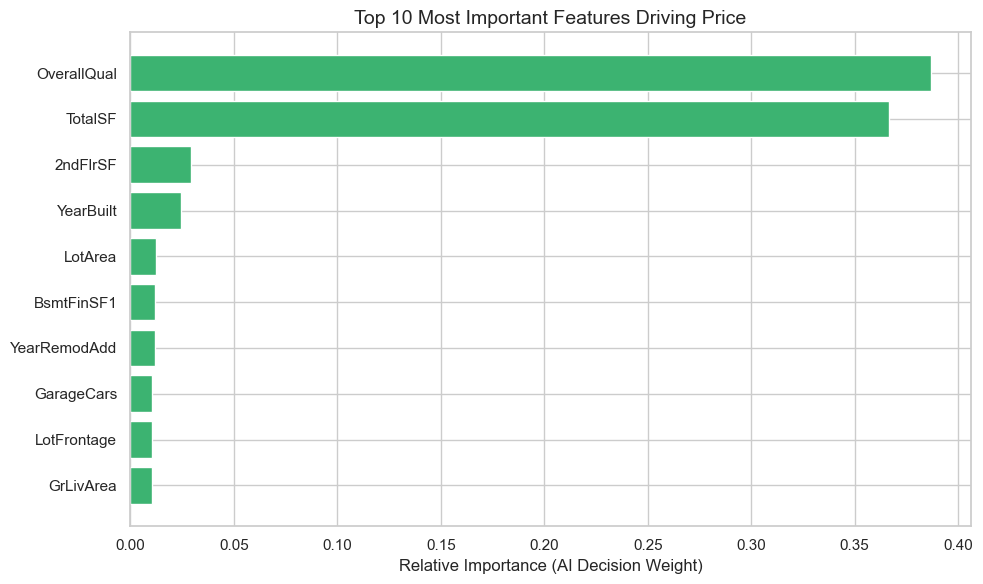

In [19]:
importances = rf_model.feature_importances_

indices = np.argsort(importances)[-10:]

plt.figure(figsize=(10, 6))
plt.barh(range(len(indices)), importances[indices], color='mediumseagreen', align='center')
plt.yticks(range(len(indices)), [features_encoded.columns[i] for i in indices])
plt.title('Top 10 Most Important Features Driving Price', fontsize=14)
plt.xlabel('Relative Importance (AI Decision Weight)')
plt.tight_layout()
plt.show()